**Pipeline complet :**
```
Images  →  EfficientNet-B4 (extraction features)  →  ACP (réduction dimensionnelle)  →  Classifieur (SVM / KNN / LR)
```

---
**Pourquoi EfficientNet-B4 ?**
- Compound scaling : profondeur + largeur + résolution optimisées simultanément
- Meilleur rapport précision/paramètres que ResNet
- Features de texture très discriminantes → idéal pour l'anti-spoofing
- Pré-entraîné sur ImageNet (1.2M images, 1000 classes)

##  Étape 1 — Installation des dépendances

In [3]:
!pip install roboflow timm -q
!pip install scikit-learn matplotlib seaborn -q
print('Installations terminées')


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: C:\Users\pc\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


Installations terminées



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: C:\Users\pc\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


## Étape 2 — Téléchargement du Dataset (Roboflow)

In [4]:
from roboflow import Roboflow

API_KEY = "SZ3rTHOR52TBYlFQeq6T"

rf = Roboflow(api_key=API_KEY)
project = rf.workspace("r-y-s").project("face-anti-spoofing-ezpqo-svq2i")
dataset = project.version(1).download("yolov8")

print(f"Dataset téléchargé dans : {dataset.location}")

ModuleNotFoundError: No module named 'roboflow'

##  Étape 3 — Exploration du Dataset (EDA)

Distribution du dataset :
Split      Real       Fake       Total
----------------------------------------
train      1333       1449       2782
valid      77         73         150
test       33         136        169


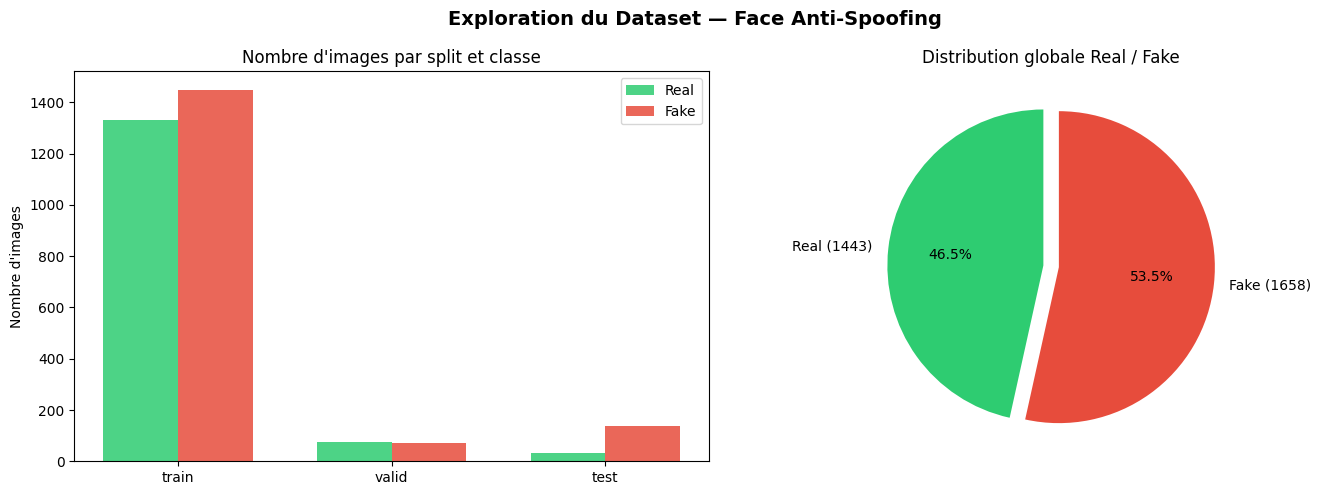

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

DATASET_PATH = dataset.location
SPLITS = ['train', 'valid', 'test']
CLASSES = ['real', 'fake']  # index 0 = real, 1 = fake (selon data.yaml)
COLORS = {'real': '#2ecc71', 'fake': '#e74c3c'}

# --- Comptage via les fichiers labels YOLOv8 ---
counts = {}
for split in SPLITS:
    counts[split] = {cls: 0 for cls in CLASSES}
    labels_path = os.path.join(DATASET_PATH, split, 'labels')
    if not os.path.exists(labels_path):
        continue
    for label_file in os.listdir(labels_path):
        if not label_file.endswith('.txt'):
            continue
        with open(os.path.join(labels_path, label_file)) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    cls_id = int(parts[0])
                    if cls_id < len(CLASSES):
                        counts[split][CLASSES[cls_id]] += 1

print('Distribution du dataset :')
print(f'{"Split":<10} {"Real":<10} {"Fake":<10} {"Total"}')
print('-' * 40)
for split in SPLITS:
    r = counts[split].get('real', 0)
    f = counts[split].get('fake', 0)
    print(f'{split:<10} {r:<10} {f:<10} {r+f}')

# --- Visualisation ---
reals = [counts[s]['real'] for s in SPLITS]
fakes = [counts[s]['fake'] for s in SPLITS]
total_real = sum(reals)
total_fake = sum(fakes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Exploration du Dataset — Face Anti-Spoofing', fontsize=14, fontweight='bold')

x = np.arange(len(SPLITS))
w = 0.35
axes[0].bar(x - w/2, reals, w, label='Real', color=COLORS['real'], alpha=0.85)
axes[0].bar(x + w/2, fakes, w, label='Fake', color=COLORS['fake'], alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(SPLITS)
axes[0].set_title("Nombre d'images par split et classe")
axes[0].legend()
axes[0].set_ylabel("Nombre d'images")

# Pie chart uniquement si données non nulles
if total_real + total_fake > 0:
    axes[1].pie(
        [total_real, total_fake],
        labels=[f'Real ({total_real})', f'Fake ({total_fake})'],
        colors=[COLORS['real'], COLORS['fake']],
        autopct='%1.1f%%', startangle=90,
        explode=(0.05, 0.05)
    )
    axes[1].set_title('Distribution globale Real / Fake')
else:
    axes[1].text(0.5, 0.5, 'Aucune donnée trouvée', ha='center', va='center')

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

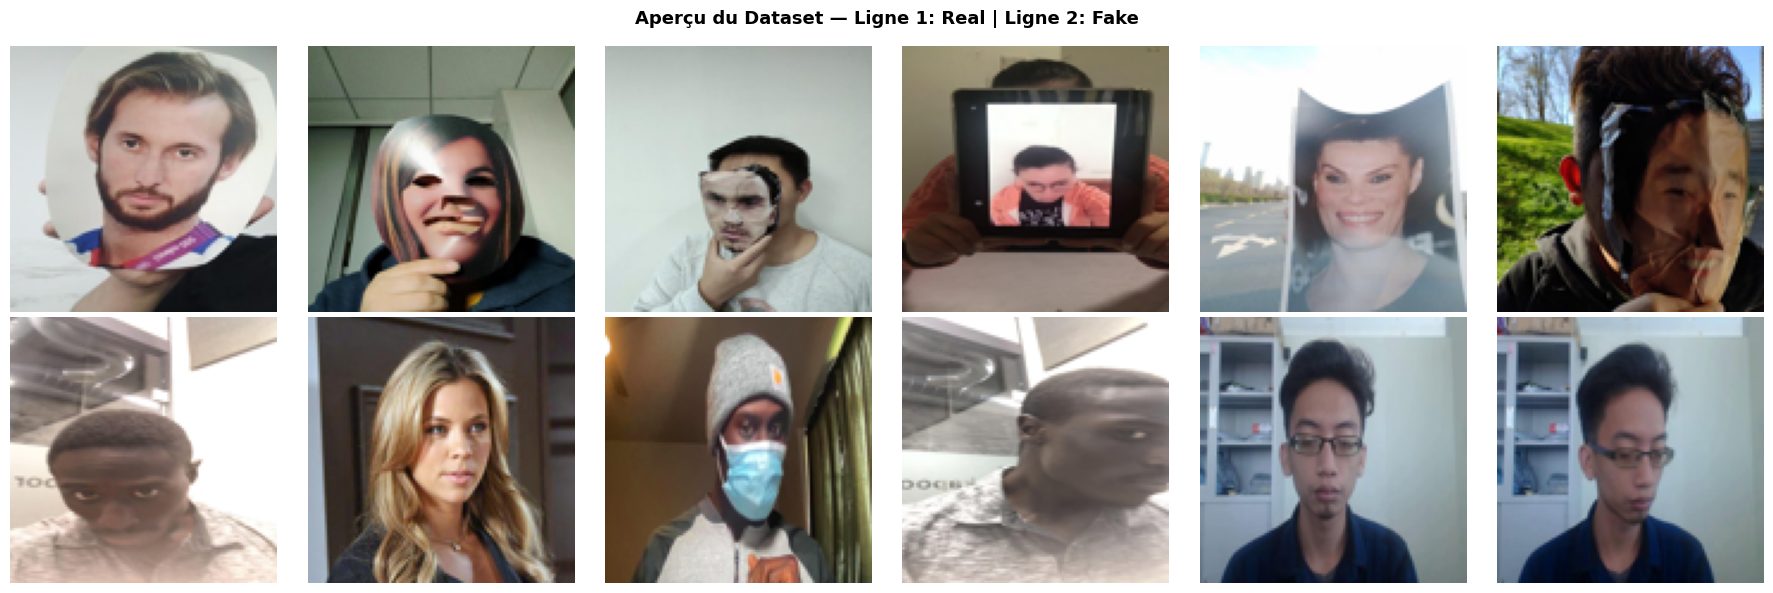

In [ ]:
from PIL import Image
import os

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Aperçu du Dataset — Ligne 1: Real | Ligne 2: Fake', fontsize=13, fontweight='bold')

# Collecter les images par classe via les labels
class_images = {cls: [] for cls in CLASSES}

labels_dir = os.path.join(DATASET_PATH, 'train', 'labels')
images_dir = os.path.join(DATASET_PATH, 'train', 'images')

for label_file in os.listdir(labels_dir):
    if not label_file.endswith('.txt'):
        continue
    with open(os.path.join(labels_dir, label_file)) as f:
        lines = f.readlines()
    if not lines:
        continue
    cls_id = int(lines[0].split()[0])  # classe de la première annotation
    cls_name = CLASSES[cls_id] if cls_id < len(CLASSES) else None
    if cls_name is None:
        continue

    # Trouver l'image correspondante
    base = os.path.splitext(label_file)[0]
    for ext in ['.jpg', '.jpeg', '.png']:
        img_path = os.path.join(images_dir, base + ext)
        if os.path.exists(img_path):
            class_images[cls_name].append(img_path)
            break

# Affichage
for row_idx, cls in enumerate(CLASSES):
    imgs = class_images[cls][:6]
    for col_idx, img_path in enumerate(imgs):
        img = Image.open(img_path).convert('RGB').resize((112, 112))
        axes[row_idx][col_idx].imshow(img)
        axes[row_idx][col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx][col_idx].set_ylabel(cls.upper(), fontsize=12,
                color=COLORS[cls], fontweight='bold')
            axes[row_idx][col_idx].yaxis.set_visible(True)
            axes[row_idx][col_idx].set_yticks([])

plt.tight_layout()
plt.savefig('eda_samples.png', dpi=150, bbox_inches='tight')
plt.show()

##  Étape 4 — Extraction de Features avec EfficientNet-B4

**Principe :** On utilise EfficientNet-B4 pré-entraîné sur ImageNet comme **extracteur de features**.  
On enlève la tête de classification finale pour récupérer un vecteur de **1792 dimensions** par image.  
Ces features encodent la texture, les contours et les patterns visuels — très discriminants pour le spoofing.

In [ ]:
import torch
import timm
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'🖥️  Device utilisé : {DEVICE}')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class FaceDataset(Dataset):
    def __init__(self, root, splits, transform=None):
        self.samples = []
        self.transform = transform

        for split in splits:
            labels_dir = os.path.join(root, split, 'labels')
            images_dir = os.path.join(root, split, 'images')
            if not os.path.exists(labels_dir):
                continue

            for label_file in os.listdir(labels_dir):
                if not label_file.endswith('.txt'):
                    continue
                label_path = os.path.join(labels_dir, label_file)
                with open(label_path) as f:
                    lines = [l.strip() for l in f if l.strip()]
                if not lines:
                    continue

                cls_id = int(lines[0].split()[0])  # 0=real, 1=fake

                base = os.path.splitext(label_file)[0]
                img_path = None
                for ext in ['.jpg', '.jpeg', '.png']:
                    candidate = os.path.join(images_dir, base + ext)
                    if os.path.exists(candidate):
                        img_path = candidate
                        break
                if img_path:
                    self.samples.append((img_path, cls_id))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

train_ds = FaceDataset(DATASET_PATH, ['train', 'valid'], transform)
test_ds  = FaceDataset(DATASET_PATH, ['test'], transform)
print(f'Train+Valid: {len(train_ds)} images | Test: {len(test_ds)} images')

NUM_WORKERS = 2 if torch.cuda.is_available() else 0  # 0 sur CPU pour éviter les deadlocks
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=NUM_WORKERS)

🖥️  Device utilisé : cuda
Train+Valid: 2441 images | Test: 97 images


In [ ]:
# --- Charger EfficientNet-B4 sans tête de classification ---
model = timm.create_model('efficientnet_b4', pretrained=True, num_classes=0, global_pool='avg')
model = model.to(DEVICE)
model.eval()

print(f'EfficientNet-B4 chargé')
print(f'   → Dimension des features : {model.num_features}')

# --- Fonction d'extraction ---
def extract_features(loader, desc='Extraction'):
    features_list, labels_list = [], []
    total = len(loader)
    with torch.no_grad():
        for i, (imgs, labels) in enumerate(loader):
            imgs = imgs.to(DEVICE)
            feats = model(imgs).cpu().numpy()
            features_list.append(feats)
            labels_list.extend(labels.numpy())
            if (i+1) % 5 == 0 or (i+1) == total:
                print(f'   [{desc}] Batch {i+1}/{total}', end='\r')
    print()
    return np.vstack(features_list), np.array(labels_list)

print(' Extraction features Train+Valid...')
X_train, y_train = extract_features(train_loader, 'Train')
print(' Extraction features Test...')
X_test,  y_test  = extract_features(test_loader,  'Test')

print(f'\n Features extraites !')
print(f'   X_train : {X_train.shape}  (n_images × {X_train.shape[1]} features)')
print(f'   X_test  : {X_test.shape}')


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

EfficientNet-B4 chargé
   → Dimension des features : 1792
 Extraction features Train+Valid...
   [Train] Batch 77/77
 Extraction features Test...
   [Test] Batch 4/4

 Features extraites !
   X_train : (2441, 1792)  (n_images × 1792 features)
   X_test  : (97, 1792)


## Étape 5 — Analyse en Composantes Principales (ACP)

**Objectif :** Réduire les 1792 features EfficientNet à un espace de dimension réduite  
en maximisant la variance expliquée — et donc l'information discriminante conservée.

✅ Normalisation StandardScaler appliquée

Variance expliquée cumulée (sur 300 composantes) :
   80% variance → 136  composantes
   90% variance → 245  composantes
   95% variance → 300 composantes
   99% variance → 300 composantes
   Variance totale couverte : 92.8%


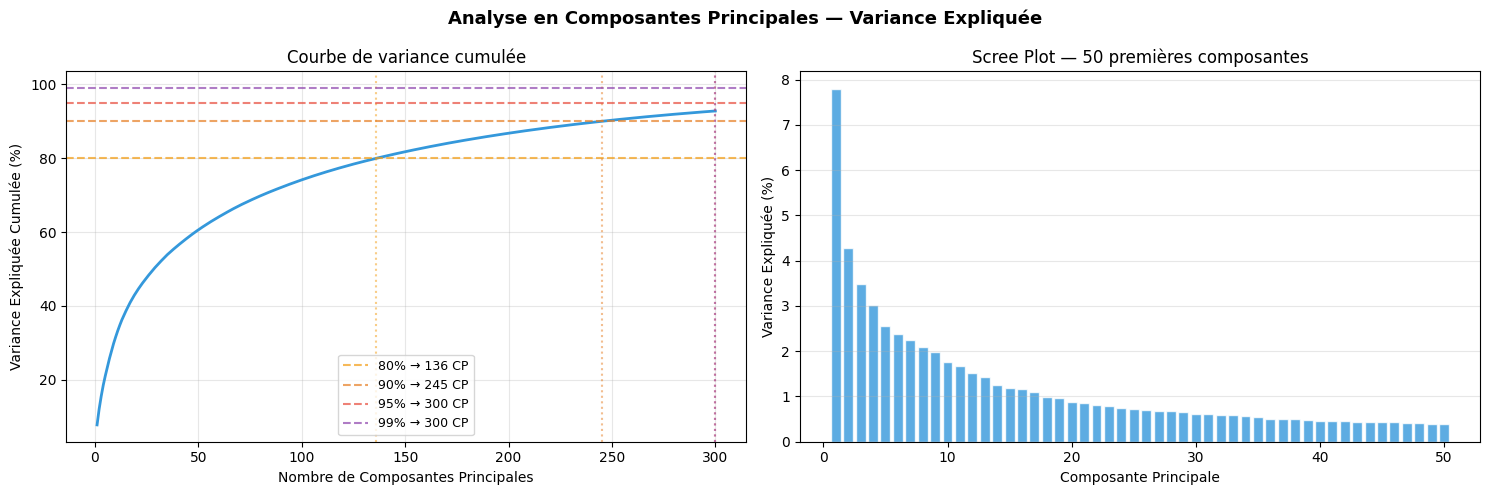


✅ Choix retenu : 300 composantes (95% variance expliquée)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Normalisation (OBLIGATOIRE avant ACP) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('✅ Normalisation StandardScaler appliquée')

# --- ACP exploratoire : variance cumulée ---
# On prend le max possible pour bien couvrir tous les seuils
n_max = min(300, X_train_scaled.shape[0] - 1, X_train_scaled.shape[1])
pca_full = PCA(n_components=n_max, random_state=42)
pca_full.fit(X_train_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

# --- Fonction robuste pour trouver le seuil ---
def find_n_components(cumvar, threshold):
    """Retourne le nombre de composantes pour atteindre `threshold`% de variance.
    Si le seuil n'est pas atteint dans les composantes calculées, retourne le max."""
    idx = np.where(cumvar >= threshold)[0]
    if len(idx) == 0:
        return len(cumvar)  # pas atteint → on prend tout
    return int(idx[0]) + 1

n_80 = find_n_components(cumvar, 80)
n_90 = find_n_components(cumvar, 90)
n_95 = find_n_components(cumvar, 95)
n_99 = find_n_components(cumvar, 99)

print(f'\nVariance expliquée cumulée (sur {n_max} composantes) :')
print(f'   80% variance → {n_80}  composantes')
print(f'   90% variance → {n_90}  composantes')
print(f'   95% variance → {n_95} composantes')
print(f'   99% variance → {n_99} composantes')
print(f'   Variance totale couverte : {cumvar[-1]:.1f}%')

# --- Courbe de variance expliquée ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Analyse en Composantes Principales — Variance Expliquée', fontsize=13, fontweight='bold')

# Variance cumulée
axes[0].plot(range(1, len(cumvar)+1), cumvar, color='#3498db', linewidth=2)
for n, pct, col in [(n_80,'80%','#f39c12'),(n_90,'90%','#e67e22'),(n_95,'95%','#e74c3c'),(n_99,'99%','#8e44ad')]:
    axes[0].axhline(y=float(pct[:-1]), color=col, linestyle='--', alpha=0.7, label=f'{pct} → {n} CP')
    axes[0].axvline(x=n, color=col, linestyle=':', alpha=0.5)
axes[0].set_xlabel('Nombre de Composantes Principales')
axes[0].set_ylabel('Variance Expliquée Cumulée (%)')
axes[0].set_title('Courbe de variance cumulée')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Scree plot (variance par composante) — 50 premières
n_scree = min(50, len(pca_full.explained_variance_ratio_))
axes[1].bar(range(1, n_scree+1), pca_full.explained_variance_ratio_[:n_scree]*100,
            color='#3498db', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Composante Principale')
axes[1].set_ylabel('Variance Expliquée (%)')
axes[1].set_title(f'Scree Plot — {n_scree} premières composantes')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('acp_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# Choix automatique à 95% (minimum 3 composantes pour les visualisations 2D/3D)
N_COMPONENTS = max(n_95, 3)
print(f'\n✅ Choix retenu : {N_COMPONENTS} composantes (95% variance expliquée)')


In [ ]:
# --- ACP finale avec N_COMPONENTS ---
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f'ACP appliquée :')
print(f'   Avant ACP : {X_train_scaled.shape[1]} dimensions')
print(f'   Après ACP : {X_train_pca.shape[1]} dimensions')
print(f'   Réduction : {(1 - X_train_pca.shape[1]/X_train_scaled.shape[1])*100:.1f}%')

ACP appliquée :
   Avant ACP : 1792 dimensions
   Après ACP : 300 dimensions
   Réduction : 83.3%


### Valeurs propres & Matrice de Corrélation

Ces deux visualisations permettent de **valider et justifier** l'ACP :
- **Valeurs propres (Scree Plot)** : combien de variance chaque axe capture, critère de Kaiser (λ ≥ 1)
- **Matrices de corrélation** : montre la redondance des features originales et l'orthogonalité parfaite des composantes après ACP

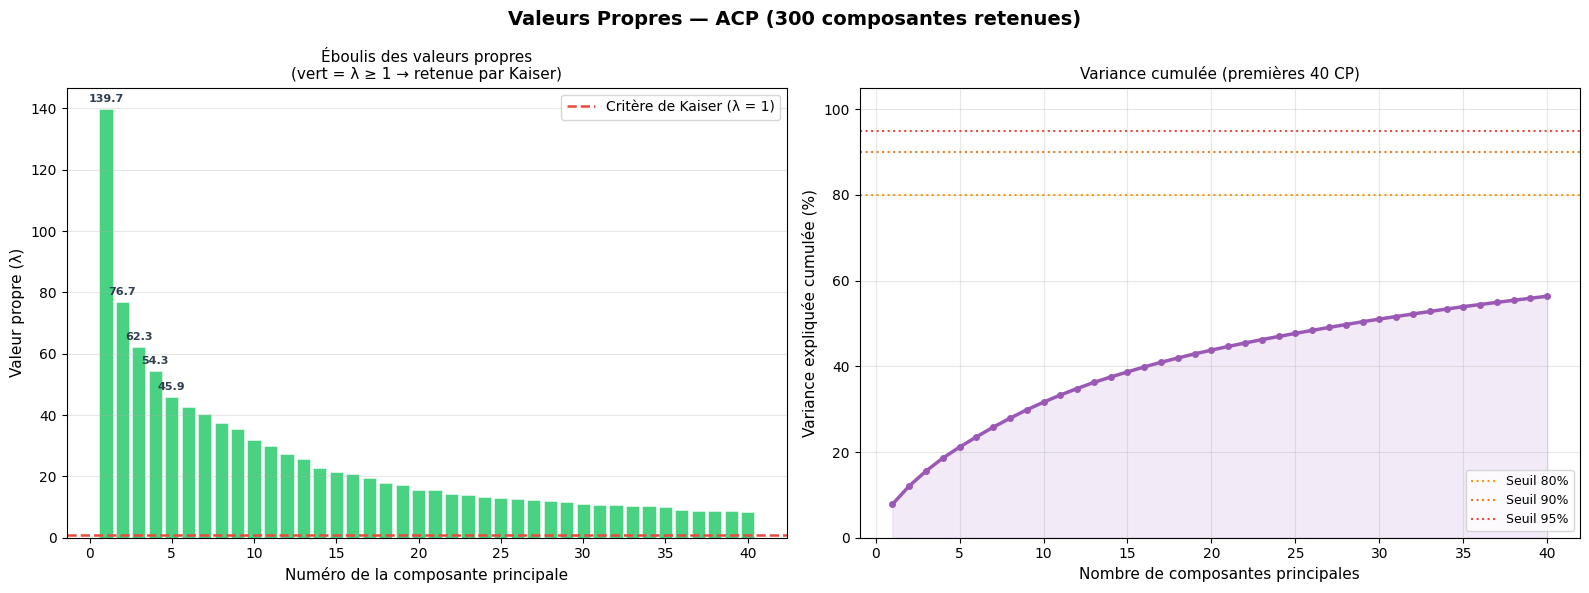


📋 Tableau des 10 premières valeurs propres :
CP     λ (valeur propre)      Variance (%)       Cumulée (%)
----------------------------------------------------------------
PC1    139.7276               7.79               7.79
PC2    76.7006                4.28               12.07
PC3    62.2912                3.47               15.55
PC4    54.3489                3.03               18.58
PC5    45.9496                2.56               21.14
PC6    42.7312                2.38               23.53
PC7    40.4726                2.26               25.78
PC8    37.4656                2.09               27.87
PC9    35.4996                1.98               29.85
PC10   31.7680                1.77               31.63

✅ CP avec λ ≥ 1 (Kaiser) : 258
✅ CP retenues (modèle)    : 300
✅ Variance totale couverte: 92.82 %


In [ ]:
# ============================================================
# VALEURS PROPRES — Éboulis (Scree Plot) + Tableau
# ============================================================
# λ_j = pca.explained_variance_[j] = variance capturée par PC_j
# Critère de Kaiser : on retient les CP avec λ >= 1
# (une CP doit expliquer au moins autant qu'une feature brute)

N_SHOW = min(40, N_COMPONENTS)

eigenvalues  = pca.explained_variance_[:N_SHOW]
var_ratio    = pca.explained_variance_ratio_[:N_SHOW] * 100
cumvar_shown = np.cumsum(pca.explained_variance_ratio_[:N_SHOW]) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'Valeurs Propres — ACP ({N_COMPONENTS} composantes retenues)',
    fontsize=14, fontweight='bold'
)

# --- Éboulis ---
ax1 = axes[0]
colors_bar = ['#2ecc71' if v >= 1 else '#3498db' for v in eigenvalues]
bars = ax1.bar(range(1, N_SHOW + 1), eigenvalues,
               color=colors_bar, alpha=0.88, edgecolor='white', linewidth=0.4)
ax1.axhline(1, color='#e74c3c', linestyle='--', linewidth=1.8,
            label='Critère de Kaiser (λ = 1)')
ax1.set_xlabel('Numéro de la composante principale', fontsize=11)
ax1.set_ylabel('Valeur propre (λ)', fontsize=11)
ax1.set_title('Éboulis des valeurs propres\n(vert = λ ≥ 1 → retenue par Kaiser)', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
# Annoter les 5 premières
for i in range(min(5, N_SHOW)):
    ax1.text(i + 1, eigenvalues[i] + eigenvalues[0] * 0.012,
             f'{eigenvalues[i]:.1f}', ha='center', va='bottom',
             fontsize=8, fontweight='bold', color='#2c3e50')

# --- Variance cumulée ---
ax2 = axes[1]
ax2.plot(range(1, N_SHOW + 1), cumvar_shown,
         color='#9b59b6', linewidth=2.5, marker='o', markersize=4)
ax2.fill_between(range(1, N_SHOW + 1), cumvar_shown, alpha=0.12, color='#9b59b6')
for threshold, col, lbl in [(80,'#f39c12','80%'), (90,'#e67e22','90%'), (95,'#e74c3c','95%')]:
    ax2.axhline(threshold, color=col, linestyle=':', linewidth=1.5, label=f'Seuil {lbl}')
ax2.set_xlabel('Nombre de composantes principales', fontsize=11)
ax2.set_ylabel('Variance expliquée cumulée (%)', fontsize=11)
ax2.set_title(f'Variance cumulée (premières {N_SHOW} CP)', fontsize=11)
ax2.set_ylim(0, 105)
ax2.legend(fontsize=9, loc='lower right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('acp_valeurs_propres.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Tableau des 10 premières ---
print("\n📋 Tableau des 10 premières valeurs propres :")
print(f"{'CP':<6} {'λ (valeur propre)':<22} {'Variance (%)':<18} {'Cumulée (%)'}")
print("-" * 64)
cumul = np.cumsum(pca.explained_variance_ratio_)
for i in range(min(10, N_COMPONENTS)):
    print(f"{'PC'+str(i+1):<6} {pca.explained_variance_[i]:<22.4f} "
          f"{pca.explained_variance_ratio_[i]*100:<18.2f} {cumul[i]*100:.2f}")

n_kaiser = int(np.sum(pca.explained_variance_ >= 1))
print(f"\n✅ CP avec λ ≥ 1 (Kaiser) : {n_kaiser}")
print(f"✅ CP retenues (modèle)    : {N_COMPONENTS}")
print(f"✅ Variance totale couverte: {pca.explained_variance_ratio_.sum()*100:.2f} %")


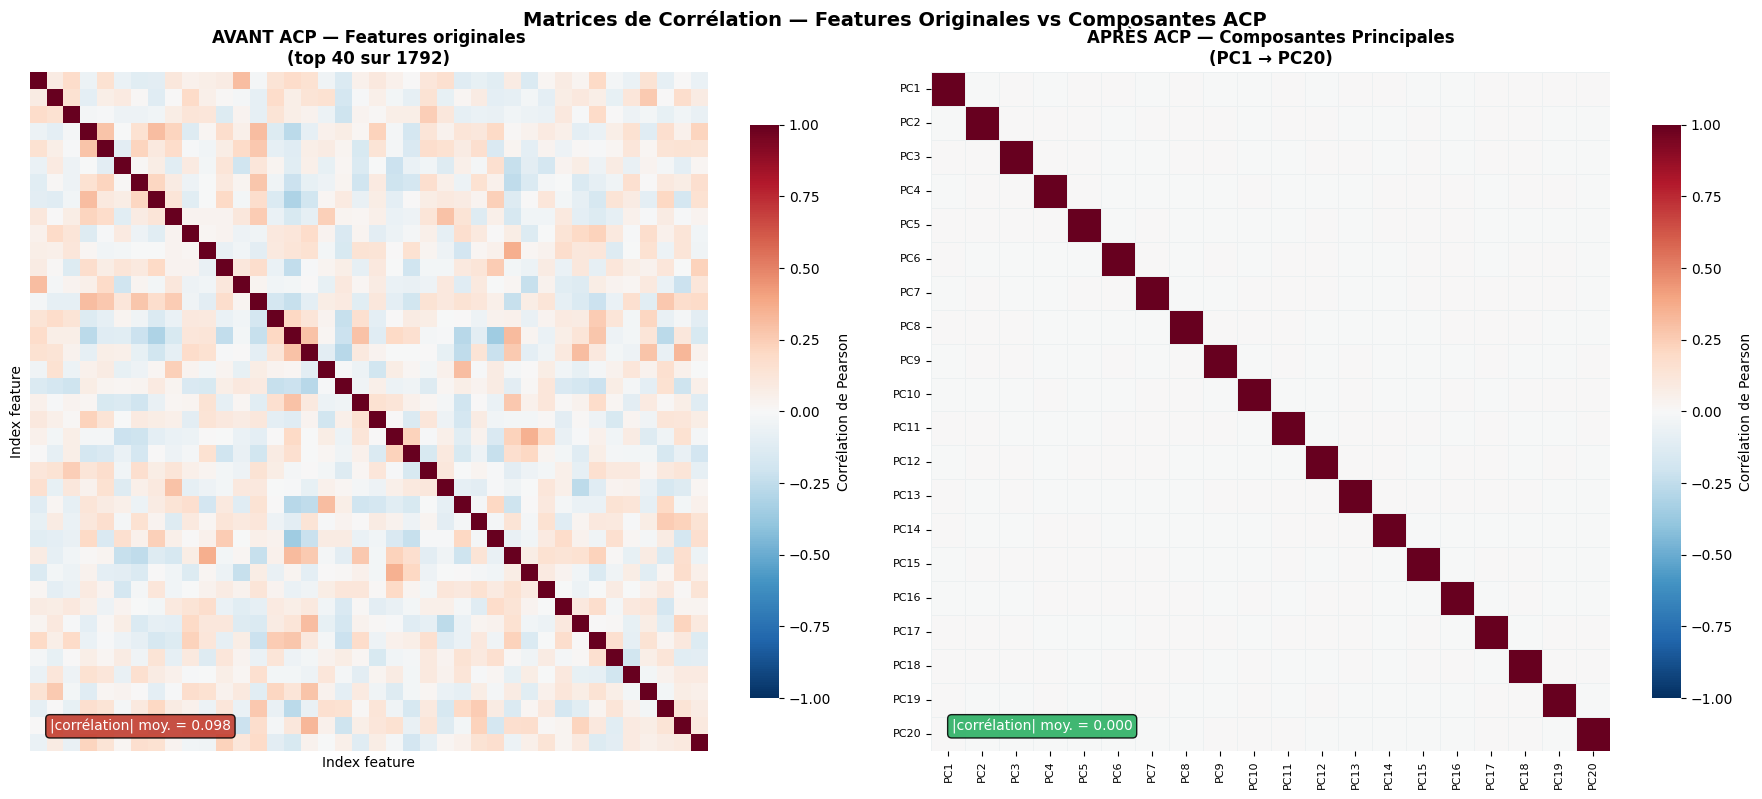

📊 Interprétation :
   Features originales  → |corrélation| moyen = 0.098  ⚠️  forte redondance
   Composantes ACP      → |corrélation| moyen = 0.000  ✅ quasi-orthogonalité
   Réduction de corrélation : facteur 998144×


In [ ]:
# ============================================================
# MATRICE DE CORRÉLATION — Avant ACP vs Après ACP
# ============================================================
# AVANT : les features EfficientNet sont fortement corrélées
#         entre elles → redondance élevée → heatmap colorée
# APRÈS : les composantes principales sont orthogonales par
#         construction → matrice quasi-identité → diagonale pure
# Ce contraste justifie l'utilité de l'ACP.

import seaborn as sns

N_CORR_ORIG = min(40, X_train.shape[1])   # features originales à afficher
N_CORR_PCA  = min(20, N_COMPONENTS)       # composantes ACP à afficher

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Matrices de Corrélation — Features Originales vs Composantes ACP',
             fontsize=14, fontweight='bold')

# --- Avant ACP : features originales standardisées ---
corr_orig = np.corrcoef(X_train_scaled[:, :N_CORR_ORIG].T)
sns.heatmap(
    corr_orig, ax=axes[0],
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0,
    cbar_kws={'label': 'Corrélation de Pearson', 'shrink': 0.78},
    xticklabels=False, yticklabels=False
)
axes[0].set_title(
    f'AVANT ACP — Features originales\n(top {N_CORR_ORIG} sur {X_train.shape[1]})',
    fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Index feature', fontsize=10)
axes[0].set_ylabel('Index feature', fontsize=10)
mask = ~np.eye(N_CORR_ORIG, dtype=bool)
mean_orig = np.abs(corr_orig[mask]).mean()
axes[0].text(0.03, 0.03, f'|corrélation| moy. = {mean_orig:.3f}',
    transform=axes[0].transAxes, fontsize=10, color='white',
    bbox=dict(boxstyle='round', fc='#c0392b', alpha=0.88))

# --- Après ACP : composantes principales ---
corr_pca = np.corrcoef(X_train_pca[:, :N_CORR_PCA].T)
labels   = [f'PC{i+1}' for i in range(N_CORR_PCA)]
sns.heatmap(
    corr_pca, ax=axes[1],
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.6, linecolor='#ecf0f1',
    cbar_kws={'label': 'Corrélation de Pearson', 'shrink': 0.78},
    annot=(N_CORR_PCA <= 15), fmt='.2f', annot_kws={'size': 7},
    xticklabels=labels, yticklabels=labels
)
axes[1].set_title(
    f'APRÈS ACP — Composantes Principales\n(PC1 → PC{N_CORR_PCA})',
    fontsize=12, fontweight='bold'
)
axes[1].tick_params(axis='x', rotation=90, labelsize=8)
axes[1].tick_params(axis='y', rotation=0,  labelsize=8)
mask_pca = ~np.eye(N_CORR_PCA, dtype=bool)
mean_pca = np.abs(corr_pca[mask_pca]).mean()
axes[1].text(0.03, 0.03, f'|corrélation| moy. = {mean_pca:.3f}',
    transform=axes[1].transAxes, fontsize=10, color='white',
    bbox=dict(boxstyle='round', fc='#27ae60', alpha=0.88))

plt.tight_layout()
plt.savefig('acp_matrice_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Interprétation :")
print(f"   Features originales  → |corrélation| moyen = {mean_orig:.3f}  ⚠️  forte redondance")
print(f"   Composantes ACP      → |corrélation| moyen = {mean_pca:.3f}  ✅ quasi-orthogonalité")
print(f"   Réduction de corrélation : facteur {mean_orig/max(mean_pca, 1e-9):.0f}×")


In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"X_train_pca shape: {X_train_pca.shape}")

X_train shape: (2441, 1792)
X_train_pca shape: (2441, 300)


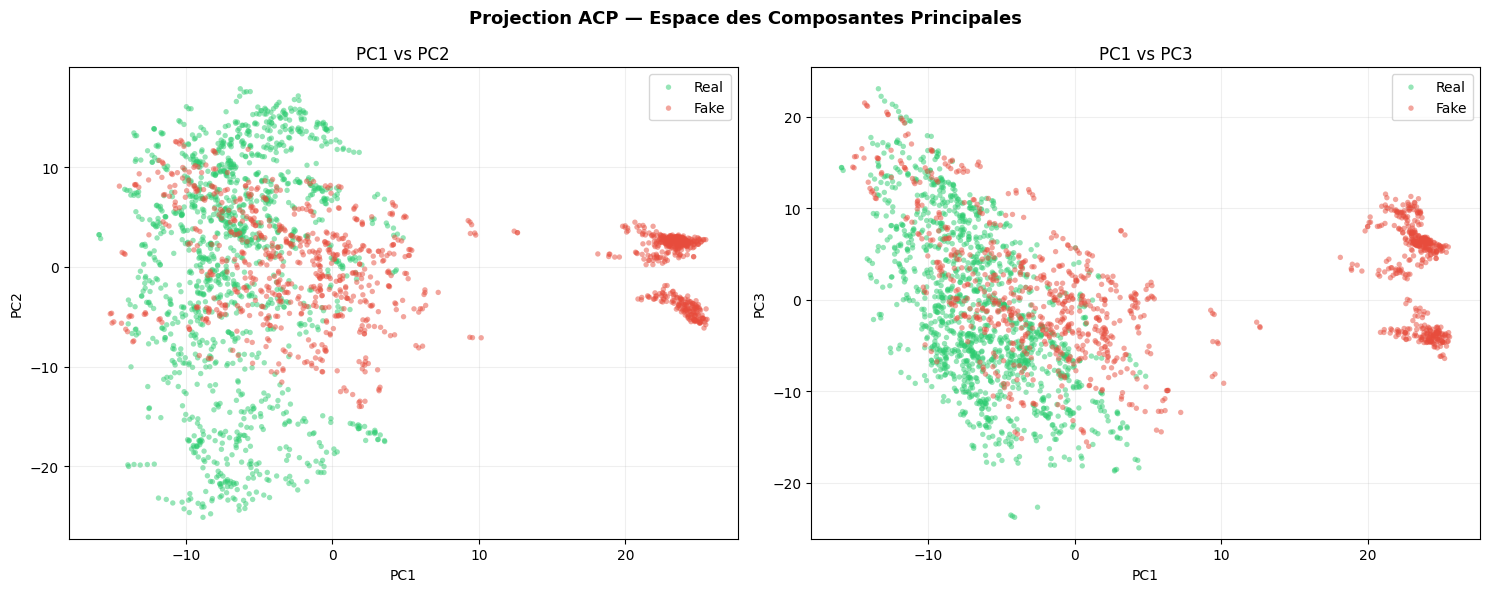

✅ Visualisation 2D générée


In [ ]:
# --- Visualisation 2D des 2 premières composantes ---
# Guard : il faut au moins 2 composantes
if X_train_pca.shape[1] < 2:
    print("⚠️  Trop peu de composantes pour la visualisation 2D (besoin de 2 min).")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Projection ACP — Espace des Composantes Principales', fontsize=13, fontweight='bold')

    label_names = {0: 'Real', 1: 'Fake'}
    colors_map  = {0: '#2ecc71', 1: '#e74c3c'}

    # PC1 vs PC2
    for lbl in [0, 1]:
        mask = y_train == lbl
        axes[0].scatter(
            X_train_pca[mask, 0], X_train_pca[mask, 1],
            c=colors_map[lbl], label=label_names[lbl],
            alpha=0.5, s=15, edgecolors='none'
        )
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    axes[0].set_title('PC1 vs PC2')
    axes[0].legend()
    axes[0].grid(alpha=0.2)

    # PC1 vs PC3 (si disponible, sinon PC2)
    pc3_idx = 2 if X_train_pca.shape[1] >= 3 else 1
    pc3_label = 'PC3' if pc3_idx == 2 else 'PC2 (PC3 indisponible)'
    for lbl in [0, 1]:
        mask = y_train == lbl
        axes[1].scatter(
            X_train_pca[mask, 0], X_train_pca[mask, pc3_idx],
            c=colors_map[lbl], label=label_names[lbl],
            alpha=0.5, s=15, edgecolors='none'
        )
    axes[1].set_xlabel('PC1')
    axes[1].set_ylabel(pc3_label)
    axes[1].set_title(f'PC1 vs {pc3_label}')
    axes[1].legend()
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.savefig('acp_projection2d.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Visualisation 2D générée")


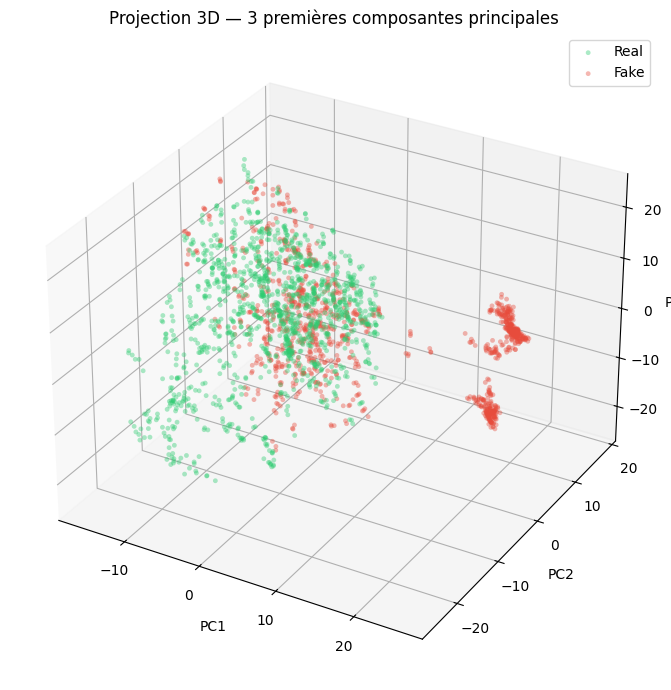

✅ Visualisation 3D générée


In [ ]:
# --- Visualisation 3D interactive ---
from mpl_toolkits.mplot3d import Axes3D

if X_train_pca.shape[1] < 3:
    print("⚠️  Trop peu de composantes pour la visualisation 3D (besoin de 3 min).")
else:
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    for lbl in [0, 1]:
        mask = y_train == lbl
        ax.scatter(
            X_train_pca[mask, 0],
            X_train_pca[mask, 1],
            X_train_pca[mask, 2],
            c=colors_map[lbl], label=label_names[lbl],
            alpha=0.4, s=12, edgecolors='none'
        )

    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.set_title('Projection 3D — 3 premières composantes principales', fontsize=12)
    ax.legend()

    plt.tight_layout()
    plt.savefig('acp_projection3d.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Visualisation 3D générée")


## Étape 5bis — Visualisations ACP : Cercle de Corrélation, Individus & Biplot

Ces trois graphiques sont les outils d'interprétation centraux d'une ACP :

- **Cercle de corrélation** : projette les *variables* (features EfficientNet) dans le plan (PC1, PC2). Un vecteur long = variable bien représentée ; vecteurs proches = variables corrélées.
- **Carte des individus** : positionne chaque *image* dans le plan factoriel. On y lit la séparation Real / Fake.
- **Biplot** : superpose les deux — permet de relier les features aux groupes d'individus.

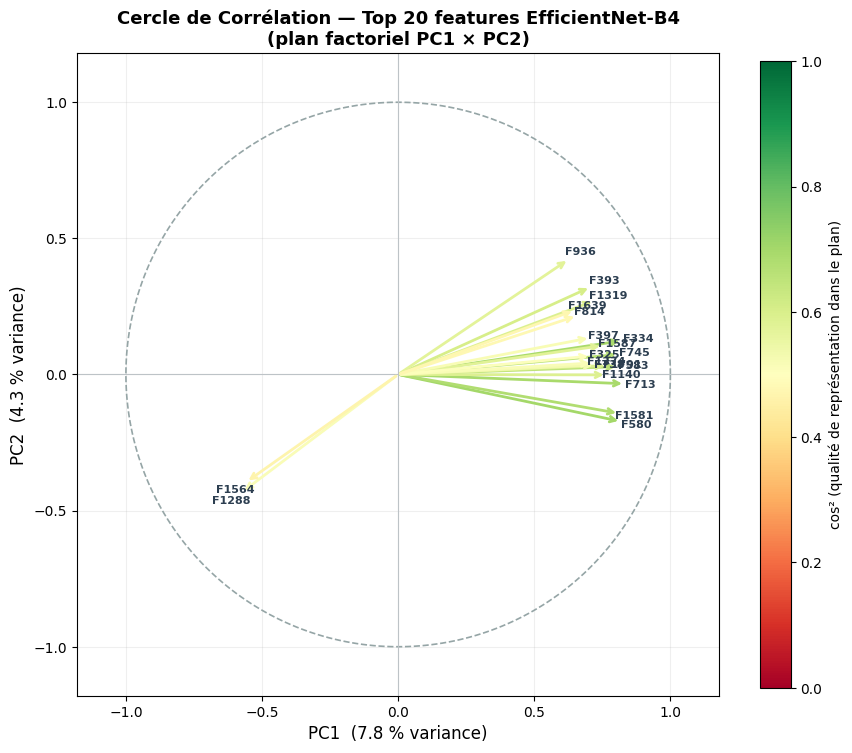

✅ Cercle de corrélation généré (20 / 1792 features affichées)
   PC1 : 7.79%  |  PC2 : 4.28%


In [ ]:
# ============================================================
# CERCLE DE CORRÉLATION (Plan PC1 × PC2)
# ============================================================
# Coordonnées de chaque variable sur les axes factoriels :
#   r(Xi, PCj) = components_[j, i] × √(explained_variance_[j])
# Pour des données standardisées, ces corrélations ∈ [-1, 1].

N_VARS_DISPLAY = 20   # top-N variables les mieux représentées dans le plan

# √ des valeurs propres pour PC1 et PC2
sqrt_ev = np.sqrt(pca.explained_variance_[:2])

# Corrélations variables-composantes : shape (n_features, 2)
var_corr = pca.components_[:2].T * sqrt_ev  # broadcasting ligne par ligne

# Qualité de représentation (cos²) = norme² dans le plan (PC1, PC2)
cos2 = var_corr[:, 0]**2 + var_corr[:, 1]**2

# Top-N variables par qualité de représentation
top_idx = np.argsort(cos2)[::-1][:N_VARS_DISPLAY]
var_names = [f'F{i}' for i in top_idx]

fig, ax = plt.subplots(figsize=(9, 9))

# Cercle unité
theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), color='#95a5a6', linewidth=1.2, linestyle='--')

# Axes du plan factoriel
ax.axhline(0, color='#bdc3c7', linewidth=0.8)
ax.axvline(0, color='#bdc3c7', linewidth=0.8)

# Colormap selon cos²
cmap_corr = plt.cm.RdYlGn
norm_cos2  = plt.Normalize(vmin=0, vmax=1)

for i, idx in enumerate(top_idx):
    xc, yc = var_corr[idx, 0], var_corr[idx, 1]
    c_rgba  = cmap_corr(norm_cos2(cos2[idx]))
    c_hex   = f'#{int(c_rgba[0]*255):02x}{int(c_rgba[1]*255):02x}{int(c_rgba[2]*255):02x}'
    ax.annotate(
        '', xy=(xc, yc), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color=c_hex, lw=2.0)
    )
    ax.text(xc * 1.07, yc * 1.07, var_names[i],
            fontsize=8, ha='center', va='center',
            color='#2c3e50', fontweight='bold')

ax.set_xlim(-1.18, 1.18)
ax.set_ylim(-1.18, 1.18)
ax.set_xlabel(f'PC1  ({pca.explained_variance_ratio_[0]*100:.1f} % variance)', fontsize=12)
ax.set_ylabel(f'PC2  ({pca.explained_variance_ratio_[1]*100:.1f} % variance)', fontsize=12)
ax.set_title(
    f'Cercle de Corrélation — Top {N_VARS_DISPLAY} features EfficientNet-B4\n'
    f'(plan factoriel PC1 × PC2)',
    fontsize=13, fontweight='bold'
)
ax.set_aspect('equal')
ax.grid(alpha=0.2)

sm = plt.cm.ScalarMappable(cmap=cmap_corr, norm=norm_cos2)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='cos² (qualité de représentation dans le plan)', shrink=0.72)

plt.tight_layout()
plt.savefig('acp_cercle_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Cercle de corrélation généré ({N_VARS_DISPLAY} / {X_train.shape[1]} features affichées)')
print(f'   PC1 : {pca.explained_variance_ratio_[0]*100:.2f}%  |  PC2 : {pca.explained_variance_ratio_[1]*100:.2f}%')


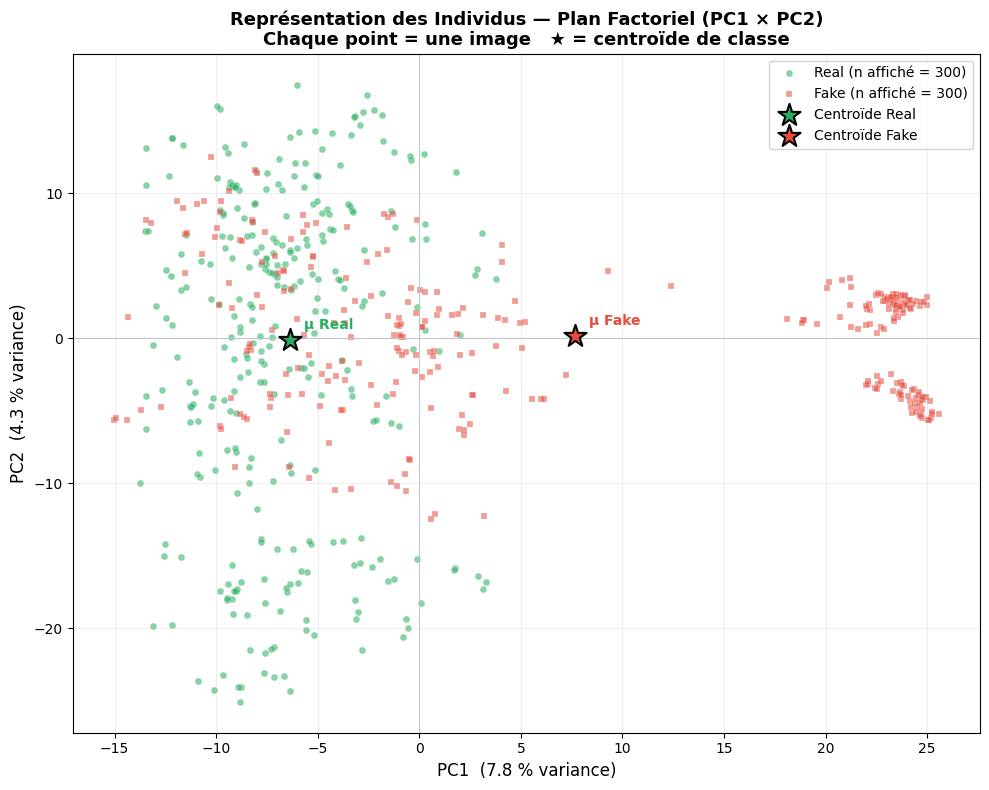

✅ Carte des individus générée


In [ ]:
# ============================================================
# REPRÉSENTATION DES INDIVIDUS (Plan PC1 × PC2)
# ============================================================
# Chaque point = une image projetée sur (PC1, PC2).
# La couleur indique la classe : Real (vert) ou Fake (rouge).
# On ajoute les centroïdes de classe (★) pour repérer les barycentres.

MAX_DISPLAY  = 600   # sous-échantillonnage pour la lisibilité
np.random.seed(42)

label_names_map = {0: 'Real', 1: 'Fake'}
colors_map_ind  = {0: '#27ae60', 1: '#e74c3c'}
markers_map_ind = {0: 'o',       1: 's'}

fig, ax = plt.subplots(figsize=(10, 8))

for lbl in [0, 1]:
    idx_lbl = np.where(y_train == lbl)[0]
    n_keep  = min(len(idx_lbl), MAX_DISPLAY // 2)
    idx_sub = np.random.choice(idx_lbl, n_keep, replace=False)

    ax.scatter(
        X_train_pca[idx_sub, 0],
        X_train_pca[idx_sub, 1],
        c=colors_map_ind[lbl],
        marker=markers_map_ind[lbl],
        label=f'{label_names_map[lbl]} (n affiché = {n_keep})',
        alpha=0.55, s=25,
        edgecolors='white', linewidths=0.3
    )

# Centroïdes des classes
for lbl in [0, 1]:
    mask_all = y_train == lbl
    cx = X_train_pca[mask_all, 0].mean()
    cy = X_train_pca[mask_all, 1].mean()
    ax.scatter(cx, cy,
               c=colors_map_ind[lbl], s=280, marker='*',
               edgecolors='black', linewidths=1.5, zorder=6,
               label=f'Centroïde {label_names_map[lbl]}')
    ax.annotate(
        f'μ {label_names_map[lbl]}', (cx, cy),
        textcoords='offset points', xytext=(10, 8),
        fontsize=10, fontweight='bold', color=colors_map_ind[lbl]
    )

ax.axhline(0, color='#bdc3c7', linewidth=0.7)
ax.axvline(0, color='#bdc3c7', linewidth=0.7)
ax.set_xlabel(f'PC1  ({pca.explained_variance_ratio_[0]*100:.1f} % variance)', fontsize=12)
ax.set_ylabel(f'PC2  ({pca.explained_variance_ratio_[1]*100:.1f} % variance)', fontsize=12)
ax.set_title(
    'Représentation des Individus — Plan Factoriel (PC1 × PC2)\n'
    'Chaque point = une image   ★ = centroïde de classe',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10, framealpha=0.85)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('acp_individus.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Carte des individus générée')


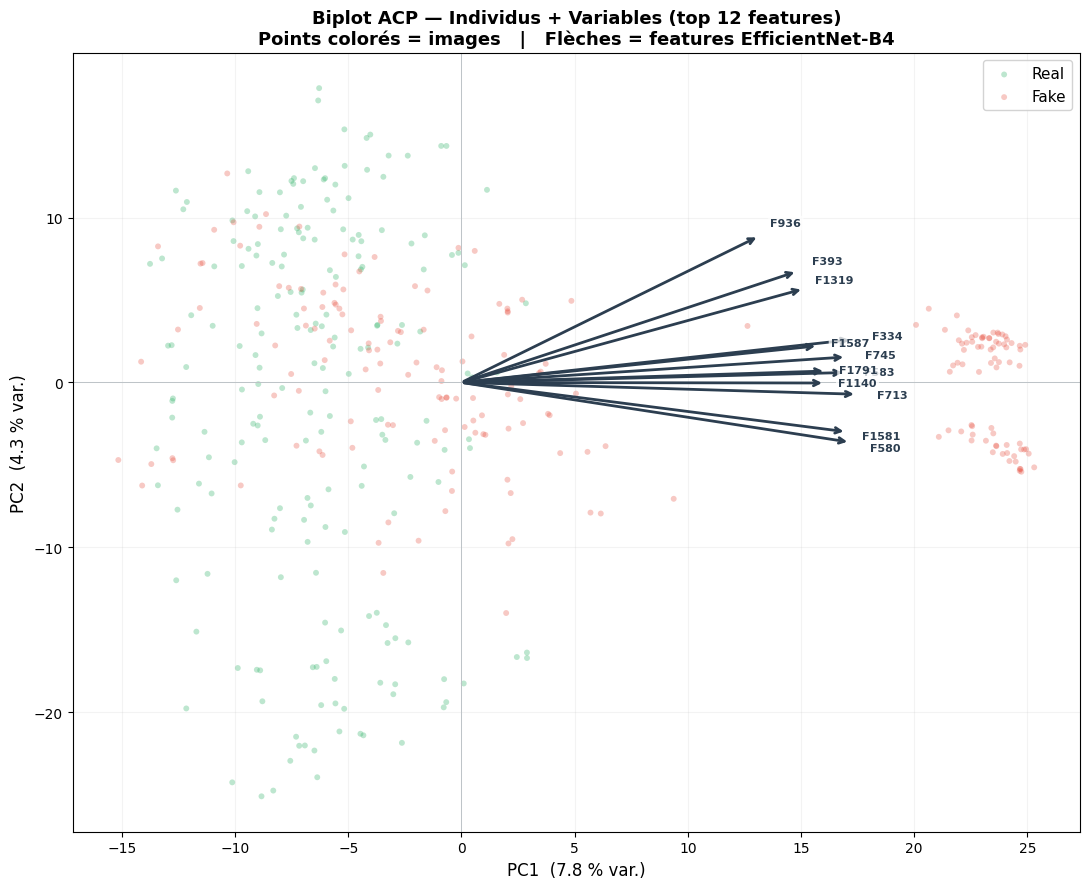

✅ Biplot généré (12 variables + individus)

📊 Comment lire ce biplot :
   → Flèche longue orientée vers les points Real (vert) : feature discriminante des vrais visages
   → Flèche longue orientée vers les points Fake (rouge) : feature discriminante des faux visages
   → Deux flèches proches → features corrélées (redondance)
   → Flèche courte → feature mal représentée dans ce plan


In [ ]:
# ============================================================
# BIPLOT — Individus + Variables superposés
# ============================================================
# Superpose la carte des individus et les vecteurs-variables.
# Les flèches sont mises à l'échelle des scores pour être lisibles.
# Interprétation : une flèche pointant vers un groupe → feature
# discriminante pour ce groupe.

N_VARS_BIPLOT  = 12    # moins de flèches pour garder la lisibilité
MAX_IND_BIPLOT = 400

fig, ax = plt.subplots(figsize=(11, 9))

# --- Individus (arrière-plan semi-transparent) ---
np.random.seed(0)
for lbl in [0, 1]:
    idx_lbl = np.where(y_train == lbl)[0]
    n_keep  = min(len(idx_lbl), MAX_IND_BIPLOT // 2)
    idx_sub = np.random.choice(idx_lbl, n_keep, replace=False)
    ax.scatter(
        X_train_pca[idx_sub, 0],
        X_train_pca[idx_sub, 1],
        c=colors_map_ind[lbl],
        label=label_names_map[lbl],
        alpha=0.30, s=18, edgecolors='none'
    )

# --- Flèches des variables (scaled) ---
# Les scores sont en unités PCA ; les corrélations sont dans [-1,1].
# → On scale les corrélations sur la plage des scores.
scale = max(
    np.abs(X_train_pca[:, 0]).max(),
    np.abs(X_train_pca[:, 1]).max()
) * 0.82

top_bi = np.argsort(cos2)[::-1][:N_VARS_BIPLOT]

for idx in top_bi:
    xc = var_corr[idx, 0] * scale
    yc = var_corr[idx, 1] * scale
    ax.annotate(
        '', xy=(xc, yc), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2.0)
    )
    ax.text(
        xc * 1.09, yc * 1.09, f'F{idx}',
        fontsize=8, color='#2c3e50', fontweight='bold',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.75, ec='none')
    )

ax.axhline(0, color='#bdc3c7', linewidth=0.7)
ax.axvline(0, color='#bdc3c7', linewidth=0.7)
ax.set_xlabel(f'PC1  ({pca.explained_variance_ratio_[0]*100:.1f} % var.)', fontsize=12)
ax.set_ylabel(f'PC2  ({pca.explained_variance_ratio_[1]*100:.1f} % var.)', fontsize=12)
ax.set_title(
    f'Biplot ACP — Individus + Variables (top {N_VARS_BIPLOT} features)\n'
    'Points colorés = images   |   Flèches = features EfficientNet-B4',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=11, framealpha=0.85)
ax.grid(alpha=0.15)

plt.tight_layout()
plt.savefig('acp_biplot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'✅ Biplot généré ({N_VARS_BIPLOT} variables + individus)')
print()
print('📊 Comment lire ce biplot :')
print('   → Flèche longue orientée vers les points Real (vert) : feature discriminante des vrais visages')
print('   → Flèche longue orientée vers les points Fake (rouge) : feature discriminante des faux visages')
print('   → Deux flèches proches → features corrélées (redondance)')
print('   → Flèche courte → feature mal représentée dans ce plan')


## Étape 6 — Classification (SVM, KNN, Régression Logistique)

On compare 3 classifieurs sur les composantes principales pour trouver le meilleur.

In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score
import time

classifiers = {
    'SVM (RBF)':             SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'KNN (k=7)':             KNeighborsClassifier(n_neighbors=7, metric='euclidean'),
    'Régression Logistique': LogisticRegression(C=1.0, max_iter=1000, random_state=42)
}

results = {}
print(' Entraînement des classifieurs...\n')

for name, clf in classifiers.items():
    t0 = time.time()
    clf.fit(X_train_pca, y_train)
    y_pred = clf.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    cv  = cross_val_score(clf, X_train_pca, y_train, cv=5, scoring='accuracy').mean()
    elapsed = time.time() - t0
    results[name] = {'clf': clf, 'y_pred': y_pred, 'acc': acc, 'cv': cv, 'time': elapsed}
    print(f'  {name:<28} Acc Test: {acc*100:.2f}%  |  CV-5: {cv*100:.2f}%  |  {elapsed:.1f}s')

best_name = max(results, key=lambda k: results[k]['acc'])
print(f'\n Meilleur classifieur : {best_name} ({results[best_name]["acc"]*100:.2f}%)')

 Entraînement des classifieurs...

  SVM (RBF)                    Acc Test: 94.85%  |  CV-5: 99.59%  |  7.6s
  KNN (k=7)                    Acc Test: 95.88%  |  CV-5: 95.29%  |  0.2s
  Régression Logistique        Acc Test: 91.75%  |  CV-5: 99.30%  |  2.1s

 Meilleur classifieur : KNN (k=7) (95.88%)


## Étape 7 — Évaluation Détaillée & Visualisations

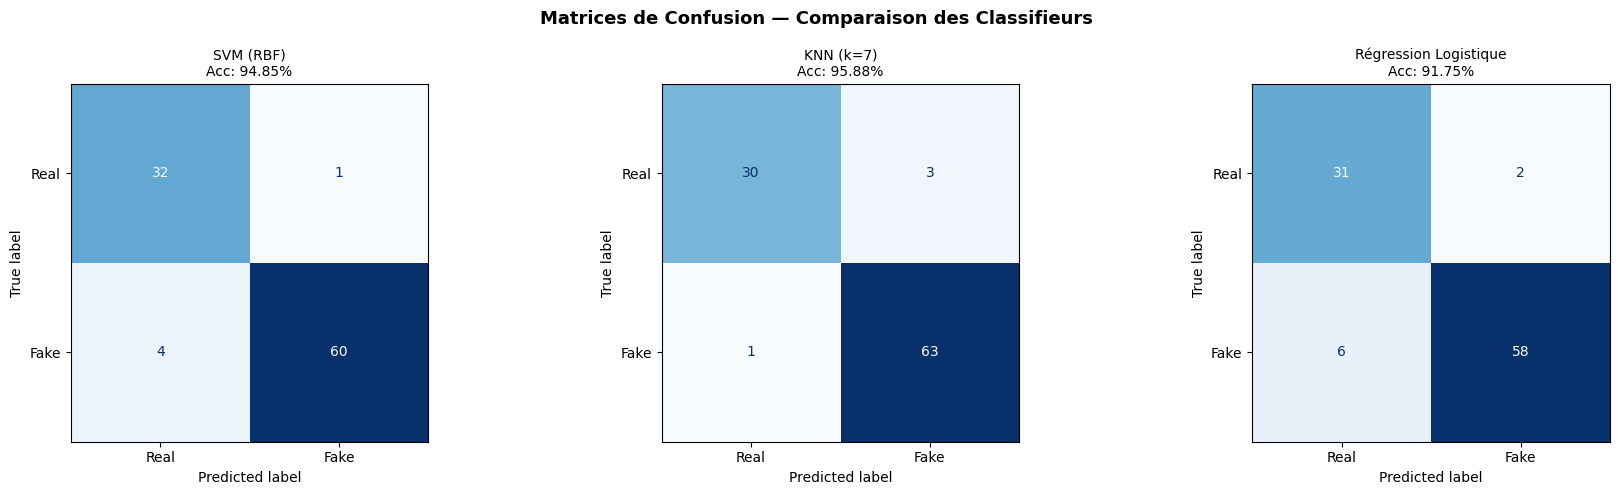

In [ ]:
# --- Matrices de confusion ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrices de Confusion — Comparaison des Classifieurs', fontsize=13, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Real', 'Fake'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc: {res["acc"]*100:.2f}%', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

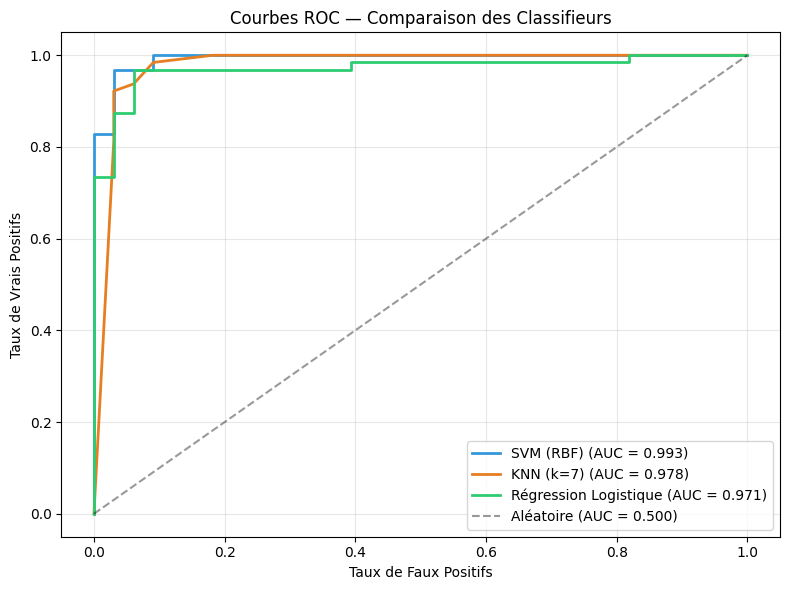

In [ ]:
# --- Courbes ROC ---
fig, ax = plt.subplots(figsize=(8, 6))
roc_colors = ['#3498db', '#e67e22', '#2ecc71']

for (name, res), color in zip(results.items(), roc_colors):
    clf = res['clf']
    if hasattr(clf, 'predict_proba'):
        y_prob = clf.predict_proba(X_test_pca)[:, 1]
    else:
        y_prob = clf.decision_function(X_test_pca)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Aléatoire (AUC = 0.500)')
ax.set_xlabel('Taux de Faux Positifs')
ax.set_ylabel('Taux de Vrais Positifs')
ax.set_title('Courbes ROC — Comparaison des Classifieurs', fontsize=12)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- Rapport de classification détaillé (meilleur modèle) ---
best = results[best_name]
print(f' Rapport détaillé — {best_name}\n')
print(classification_report(y_test, best['y_pred'], target_names=['Real', 'Fake']))

 Rapport détaillé — KNN (k=7)

              precision    recall  f1-score   support

        Real       0.97      0.91      0.94        33
        Fake       0.95      0.98      0.97        64

    accuracy                           0.96        97
   macro avg       0.96      0.95      0.95        97
weighted avg       0.96      0.96      0.96        97



 Analyse de sensibilité : n_components vs accuracy...
   n=  10 composantes → 89.69%
   n=  20 composantes → 94.85%
   n=  50 composantes → 96.91%
   n=  80 composantes → 96.91%
   n= 150 composantes → 96.91%
   n= 200 composantes → 94.85%


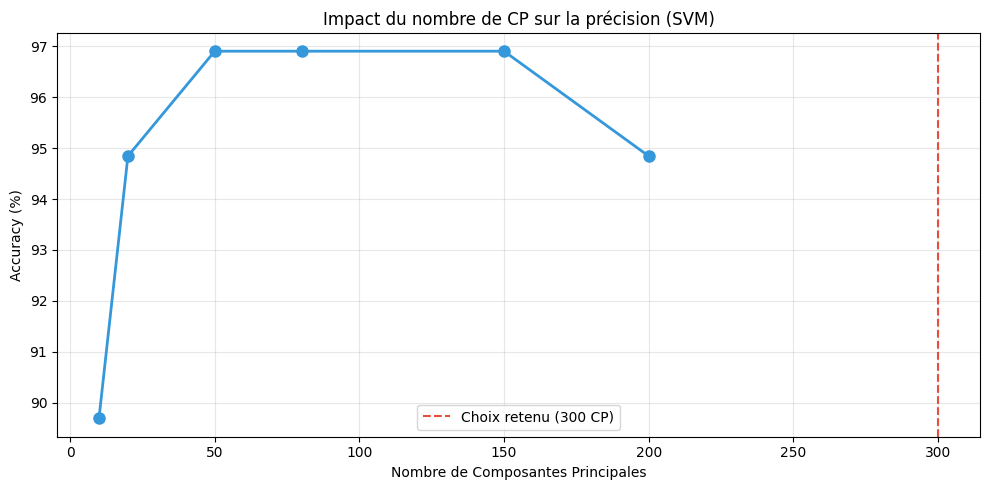

In [ ]:
# --- Impact du nombre de composantes sur la précision ---
print(' Analyse de sensibilité : n_components vs accuracy...')
n_range = [10, 20, 50, 80, n_90, n_95, n_99, 150, 200]
n_range = sorted(set([n for n in n_range if 1 < n <= min(200, X_train_scaled.shape[1], X_train_scaled.shape[0]-1)]))

accs_svm = []
best_clf_class = classifiers[best_name].__class__

for n in n_range:
    pca_tmp = PCA(n_components=n, random_state=42)
    Xtr = pca_tmp.fit_transform(X_train_scaled)
    Xte = pca_tmp.transform(X_test_scaled)
    clf_tmp = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
    clf_tmp.fit(Xtr, y_train)
    accs_svm.append(accuracy_score(y_test, clf_tmp.predict(Xte)) * 100)
    print(f'   n={n:>4} composantes → {accs_svm[-1]:.2f}%')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_range, accs_svm, 'o-', color='#3498db', linewidth=2, markersize=8)
ax.axvline(x=N_COMPONENTS, color='#e74c3c', linestyle='--', label=f'Choix retenu ({N_COMPONENTS} CP)')
ax.set_xlabel('Nombre de Composantes Principales')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Impact du nombre de CP sur la précision (SVM)', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('sensitivity_ncomponents.png', dpi=150, bbox_inches='tight')
plt.show()

## Étape 8 — Prédiction sur une nouvelle image

Image testée : mask-wearing-1632939946695_png_jpg.rf.60f982caaf91f2bc6d8377b730344aba.jpg
Label réel  : Fake


Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.


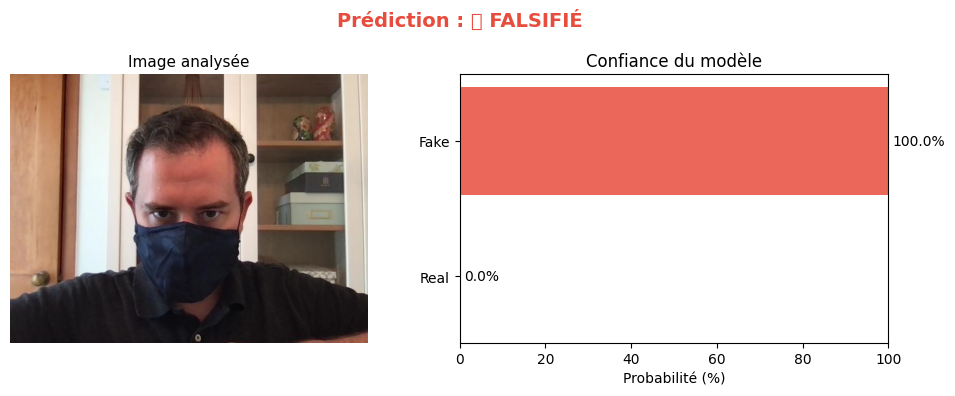

In [ ]:
def predict_image(image_path):
    """
    Prédit si une image de visage est RÉELLE ou FALSIFIÉE.
    Utilise le pipeline complet : EfficientNet-B4 → ACP → SVM
    """
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        feat = model(img_tensor).cpu().numpy()

    feat_scaled = scaler.transform(feat)
    feat_pca    = pca.transform(feat_scaled)

    best_clf = results[best_name]['clf']
    pred     = best_clf.predict(feat_pca)[0]
    proba    = best_clf.predict_proba(feat_pca)[0] if hasattr(best_clf, 'predict_proba') else None

    label = '✅ RÉEL' if pred == 0 else '❌ FALSIFIÉ'
    color = '#2ecc71' if pred == 0 else '#e74c3c'

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img)
    axes[0].axis('off')
    axes[0].set_title(f'Image analysée', fontsize=11)

    if proba is not None:
        axes[1].barh(['Real', 'Fake'], proba * 100,
                     color=['#2ecc71', '#e74c3c'], alpha=0.85)
        axes[1].set_xlim(0, 100)
        axes[1].set_xlabel('Probabilité (%)')
        axes[1].set_title('Confiance du modèle')
        for i, v in enumerate(proba * 100):
            axes[1].text(v + 1, i, f'{v:.1f}%', va='center')

    fig.suptitle(f'Prédiction : {label}', fontsize=14,
                 fontweight='bold', color=color)
    plt.tight_layout()
    plt.show()
    return label

# --- Test sur une image du dataset de test ---
sample_imgs = test_ds.samples
if sample_imgs:
    sample_path, true_label = sample_imgs[0]
    print(f'Image testée : {os.path.basename(sample_path)}')
    print(f'Label réel  : {"Real" if true_label == 0 else "Fake"}')
    predict_image(sample_path)

##  Étape 9 — Résumé Final du Projet

In [ ]:
print('=' * 60)
print('  RÉSUMÉ — Détection de Visage Réel ou Falsifié')
print('=' * 60)
print(f'\n  Dataset       : Face Anti-Spoofing (Roboflow)')
print(f'  Classes       : Real (0) | Fake (1)')
print(f'  Train+Valid   : {len(train_ds)} images')
print(f'  Test          : {len(test_ds)} images')
print(f'\n  Extracteur    : EfficientNet-B4 (ImageNet pré-entraîné)')
print(f'  Features brut : {X_train.shape[1]} dimensions')
print(f'  ACP           : {N_COMPONENTS} composantes (95% variance)')
print(f'  Réduction     : {(1 - N_COMPONENTS/X_train.shape[1])*100:.1f}%')
print()
print(f'  {"Classifieur":<30} {"Test Acc":>10}  {"CV-5 Acc":>10}')
print(f'  {"-"*52}')
for name, res in results.items():
    flag = 'x' if name == best_name else ''
    print(f'  {name:<30} {res["acc"]*100:>9.2f}%  {res["cv"]*100:>9.2f}%{flag}')
print('=' * 60)

  RÉSUMÉ — Détection de Visage Réel ou Falsifié

  Dataset       : Face Anti-Spoofing (Roboflow)
  Classes       : Real (0) | Fake (1)
  Train+Valid   : 2441 images
  Test          : 97 images

  Extracteur    : EfficientNet-B4 (ImageNet pré-entraîné)
  Features brut : 1792 dimensions
  ACP           : 300 composantes (95% variance)
  Réduction     : 83.3%

  Classifieur                      Test Acc    CV-5 Acc
  ----------------------------------------------------
  SVM (RBF)                          94.85%      99.59%
  KNN (k=7)                          95.88%      95.29%x
  Régression Logistique              91.75%      99.30%
